In [ ]:
# @title 폰트 설치 및 Matplotlib 설정 (한글 깨짐 방지)
# 런타임 재시작 필요 없음

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

print("✅ 나눔 폰트 설치 및 Matplotlib 설정 완료.")
print("이제 시각화 셀을 다시 실행하시면 한글이 정상적으로 표시됩니다.")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

# **데이터 수집 -BHC**

In [ ]:
# [셀 1] 필수 라이브러리 설치 및 임포트
!pip install google-api-python-client pandas openpyxl tqdm

import os
import math
import pandas as pd
from googleapiclient.discovery import build
from google.colab import drive, userdata
from tqdm.notebook import tqdm

print("✅ 라이브러리 설치 및 임포트 완료")


✅ 라이브러리 설치 및 임포트 완료


In [ ]:
# [셀 2] 구글 드라이브 마운트 및 저장 경로 설정 함수

# 구글 드라이브 마운트
drive.mount('/content/drive')

def create_directory(path: str):
    """폴더가 없으면 생성하고, 있으면 그대로 사용"""
    if not os.path.exists(path):
        os.makedirs(path)
        print(f"📁 폴더가 생성되었습니다: {path}")
    else:
        print(f"📁 폴더가 이미 존재합니다: {path}")


Mounted at /content/drive


In [ ]:
# [셀 3] 사용자 설정 변수 (이곳만 수정하면 됨)
from datetime import datetime, timedelta, timezone

# 1. 저장할 폴더 경로
SAVE_FOLDER_PATH = "/content/drive/MyDrive/YoutubeData"

# 2. 저장할 파일 이름 (엑셀)
SAVE_FILENAME = "bhc_스윗칠리킹_댓글.xlsx"

# 3. 유튜브 검색 조건 설정
#    - BHC 신메뉴 "스윗칠리킹" 리뷰/먹방 중심 키워드
SEARCH_QUERIES = [
    "bhc 스윗칠리킹 리뷰",
    "bhc 스윗칠리킹 먹방",
    "BHC 스윗칠리킹 신메뉴 리뷰",
    "비에이치씨 스윗칠리킹 리뷰",
]

# 4. 최근 n개월 이내 영상만 검색
MONTH_RANGE = 3   # 필요하면 3 → 6 등으로 조정

# 5. 최소 댓글 개수 필터 (유튜브 통계 기준)
MIN_COMMENTS = 150   # 200개 이상인 영상만 수집

# 6. 최대 영상 개수 (중복 제거 후 대략적인 상한)
MAX_VIDEOS = 80

# --- 자동 생성 변수 ---
create_directory(SAVE_FOLDER_PATH)
FULL_SAVE_PATH = os.path.join(SAVE_FOLDER_PATH, SAVE_FILENAME)

# 검색 시작 시점 (UTC 기준)
now_utc = datetime.now(timezone.utc)
published_after_dt = now_utc - timedelta(days=30 * MONTH_RANGE)
PUBLISHED_AFTER = published_after_dt.isoformat().replace("+00:00", "Z")

print("✅ 설정 완료")
print(f"  - 저장 경로: {FULL_SAVE_PATH}")
print(f"  - 검색 기간: {published_after_dt.date()} ~ {now_utc.date()}")
print(f"  - 검색 키워드: {SEARCH_QUERIES}")
print(f"  - 최소 댓글 수: {MIN_COMMENTS}개")


📁 폴더가 이미 존재합니다: /content/drive/MyDrive/YoutubeData
✅ 설정 완료
  - 저장 경로: /content/drive/MyDrive/YoutubeData/bhc_스윗칠리킹_댓글.xlsx
  - 검색 기간: 2025-08-30 ~ 2025-11-28
  - 검색 키워드: ['bhc 스윗칠리킹 리뷰', 'bhc 스윗칠리킹 먹방', 'BHC 스윗칠리킹 신메뉴 리뷰', '비에이치씨 스윗칠리킹 리뷰']
  - 최소 댓글 수: 150개


In [ ]:
# [셀 4] 유튜브 API 연결 및 수집 함수 정의

# 1. YouTube API 클라이언트 생성 (Colab Secrets에 'youtube' 키 필요)
youtube = None
try:
    api_key = userdata.get('youtube')
    if not api_key:
        raise ValueError("Colab Secrets에 'youtube' 이름으로 API 키가 없습니다.")
    youtube = build('youtube', 'v3', developerKey=api_key)
    print("✅ YouTube API 연결 성공")
except Exception as e:
    print(f"❌ YouTube API 연결 실패: {e}")
    print("   → 메뉴: 도구 > 사용자 비밀(Secrets)에서 'youtube' 키를 확인하세요.")


def get_video_details(video_id: str):
    """영상의 제목, 채널명, 게시일, 총 댓글 수 등 기본 정보를 가져옴"""
    try:
        request = youtube.videos().list(
            part='snippet,statistics',
            id=video_id
        )
        response = request.execute()
        items = response.get('items', [])
        if not items:
            print(f"❌ 영상을 찾을 수 없습니다: {video_id}")
            return None

        item = items[0]
        snippet = item['snippet']
        stats = item.get('statistics', {})

        info = {
            "video_id": video_id,
            "video_title": snippet.get("title", ""),
            "channel_title": snippet.get("channelTitle", ""),
            "video_published_at": snippet.get("publishedAt"),
            "total_comment_count": int(stats.get("commentCount", 0)),
        }

        return info

    except Exception as e:
        print(f"❌ get_video_details 중 오류 발생 ({video_id}): {e}")
        return None


def fetch_comments(video_id: str, video_info: dict):
    """
    단일 영상의 모든 댓글(대댓글 포함)을 수집하여 리스트로 반환.
    각 댓글은 dict 형태로 저장.
    """
    comments_data = []
    total_comments = video_info.get("total_comment_count", 0)

    # 진행상황 표시용
    pbar = tqdm(
        total=total_comments if total_comments > 0 else None,
        desc=f"댓글 수집 중: {video_info['video_title'][:30]}...",
        unit="comment"
    )

    try:
        next_page_token = None

        while True:
            request = youtube.commentThreads().list(
                part='snippet,replies',
                videoId=video_id,
                maxResults=100,
                textFormat='plainText',
                pageToken=next_page_token
            )
            response = request.execute()

            for item in response.get('items', []):
                # 상위 댓글
                top_comment = item['snippet']['topLevelComment']
                top_snippet = top_comment['snippet']

                top_data = {
                    "video_id": video_id,
                    "video_title": video_info["video_title"],
                    "channel_title": video_info["channel_title"],
                    "video_published_at": video_info["video_published_at"],
                    "total_comment_count": video_info["total_comment_count"],
                    "comment_id": top_comment["id"],
                    "parent_comment_id": None,
                    "author": top_snippet.get("authorDisplayName"),
                    "like_count": top_snippet.get("likeCount", 0),
                    "published_at": top_snippet.get("publishedAt"),
                    "updated_at": top_snippet.get("updatedAt"),
                    "text": top_snippet.get("textDisplay"),
                    "is_reply": False,
                }
                comments_data.append(top_data)
                pbar.update(1)

                # 대댓글(replies)
                replies = item.get("replies", {}).get("comments", [])
                for reply in replies:
                    reply_snippet = reply["snippet"]
                    reply_data = {
                        "video_id": video_id,
                        "video_title": video_info["video_title"],
                        "channel_title": video_info["channel_title"],
                        "video_published_at": video_info["video_published_at"],
                        "total_comment_count": video_info["total_comment_count"],
                        "comment_id": reply["id"],
                        "parent_comment_id": top_comment["id"],
                        "author": reply_snippet.get("authorDisplayName"),
                        "like_count": reply_snippet.get("likeCount", 0),
                        "published_at": reply_snippet.get("publishedAt"),
                        "updated_at": reply_snippet.get("UpdatedAt", reply_snippet.get("publishedAt")),
                        "text": reply_snippet.get("textDisplay"),
                        "is_reply": True,
                    }
                    comments_data.append(reply_data)
                    pbar.update(1)

            next_page_token = response.get("nextPageToken")
            if not next_page_token:
                break

    except Exception as e:
        print(f"\n❌ 댓글 수집 중 오류 발생 ({video_id}): {e}")
    finally:
        pbar.close()

    print(f"   → 최종 수집 댓글 수: {len(comments_data)}개")
    return comments_data


✅ YouTube API 연결 성공


In [ ]:
# [셀 5] 최근 3개월 BHC '스윗칠리킹' 리뷰 영상 검색

if youtube is None:
    print("❌ YouTube 클라이언트가 없습니다. [셀 4]를 다시 확인하세요.")
else:
    print(f"📅 검색 기간: {published_after_dt.date()} ~ {now_utc.date()}")
    print(f"🔎 검색 키워드: {SEARCH_QUERIES}")
    print(f"⚙️ 최소 댓글 수 필터: {MIN_COMMENTS}개")

    found_videos = {}  # video_id -> 메타정보

    for query in SEARCH_QUERIES:
        print(f"\n🔍 키워드 검색 중: '{query}'")
        next_page_token = None
        fetched_for_query = 0

        while True:
            search_request = youtube.search().list(
                part="snippet",
                q=query,
                type="video",
                maxResults=50,
                order="viewCount",       # 조회수 순
                publishedAfter=PUBLISHED_AFTER,
                pageToken=next_page_token
            )
            search_response = search_request.execute()

            for item in search_response.get("items", []):
                video_id = item["id"]["videoId"]
                snippet = item["snippet"]
                title = snippet.get("title", "")
                desc = snippet.get("description", "")

                # ✅ 필수 조건: 제목/설명에 "스윗칠리킹" 포함
                if "스윗칠리킹" not in title and "스윗칠리킹" not in desc:
                    continue

                # (선택) BHC 관련 추가 필터를 걸고 싶으면 아래 주석 해제
                # lower_title = title.lower()
                # if "bhc" not in lower_title and "비에이치씨" not in title:
                #     continue

                if video_id not in found_videos:
                    found_videos[video_id] = {
                        "video_id": video_id,
                        "title": title,
                        "channel_title": snippet.get("channelTitle", ""),
                        "published_at": snippet.get("publishedAt", ""),
                        "search_query": query,
                    }
                    fetched_for_query += 1

                    if len(found_videos) >= MAX_VIDEOS:
                        print("⚠️ MAX_VIDEOS에 도달하여 검색을 중단합니다.")
                        break

            if len(found_videos) >= MAX_VIDEOS:
                break

            next_page_token = search_response.get("nextPageToken")
            if not next_page_token:
                break

        print(f"  ↳ '{query}'로 '스윗칠리킹' 조건을 만족한 영상 수: {fetched_for_query}개")

    print("\n✅ 최종 선택된 영상 수(중복 제거 후):", len(found_videos))
    for vid, info in list(found_videos.items())[:5]:
        print(f" - {info['title']} | {info['channel_title']} | {info['published_at']}")


📅 검색 기간: 2025-08-30 ~ 2025-11-28
🔎 검색 키워드: ['bhc 스윗칠리킹 리뷰', 'bhc 스윗칠리킹 먹방', 'BHC 스윗칠리킹 신메뉴 리뷰', '비에이치씨 스윗칠리킹 리뷰']
⚙️ 최소 댓글 수 필터: 150개

🔍 키워드 검색 중: 'bhc 스윗칠리킹 리뷰'
  ↳ 'bhc 스윗칠리킹 리뷰'로 '스윗칠리킹' 조건을 만족한 영상 수: 16개

🔍 키워드 검색 중: 'bhc 스윗칠리킹 먹방'
  ↳ 'bhc 스윗칠리킹 먹방'로 '스윗칠리킹' 조건을 만족한 영상 수: 13개

🔍 키워드 검색 중: 'BHC 스윗칠리킹 신메뉴 리뷰'
  ↳ 'BHC 스윗칠리킹 신메뉴 리뷰'로 '스윗칠리킹' 조건을 만족한 영상 수: 0개

🔍 키워드 검색 중: '비에이치씨 스윗칠리킹 리뷰'
  ↳ '비에이치씨 스윗칠리킹 리뷰'로 '스윗칠리킹' 조건을 만족한 영상 수: 0개

✅ 최종 선택된 영상 수(중복 제거 후): 29
 - BHC에서 바삭한 양념치킨이 나왔다고? 이거 진짜 바삭함? | 흑백리뷰 | 2025-11-18T08:41:01Z
 - 자칭 극한의 바삭한 양념치킨 | 두맨 | 2025-11-20T02:30:51Z
 - 당신이 모를 수도 있는 치킨 ㄷㄷ | 냠냠 | 2025-11-21T10:03:12Z
 - 말차떡볶이.. 이게 웨 맛있어? 먹방VLOG | bhc스윗칠리킹 요아정저당딸기 맥도날드트러플치즈 코코로카라신메뉴 과자신상 말차크림떡볶이&amp;말차버갈튀 편의점신상 | 찌콩먹콩 zzicong | 2025-11-25T10:11:28Z
 - bhc 스윗칠리킹 신메뉴 솔직한 리뷰! 바삭한 양념치킨? | 리뷰는 유나인 | 2025-11-20T12:44:34Z


In [ ]:
# [셀 6] '스윗칠리킹' + 댓글 200개 이상 영상만 댓글 수집 후 엑셀 저장

if youtube is None:
    print("❌ YouTube 클라이언트가 없습니다. [셀 4]를 다시 확인하세요.")
elif not found_videos:
    print("❌ 조건을 만족하는 영상이 없습니다. [셀 5] 검색 결과를 확인하세요.")
else:
    print("\n📥 여러 영상의 댓글 수집을 시작합니다...")
    print(f"   (조건: 제목/설명에 '스윗칠리킹' 포함 + 댓글 {MIN_COMMENTS}개 이상)")

    all_comments = []

    for video_id, meta in tqdm(found_videos.items(), desc="영상별 처리", unit="video"):
        video_info = get_video_details(video_id)
        if video_info is None:
            print(f"⚠️ 영상 정보를 가져올 수 없어 스킵: {video_id}")
            continue

        total_comments = video_info["total_comment_count"]

        # 댓글 수 필터
        if total_comments < MIN_COMMENTS:
            print(f"❎ [{video_info['video_title']}] → 댓글 {total_comments}개 (기준 {MIN_COMMENTS}개 미만) → 스킵")
            continue

        print(f"\n🎬 [{video_info['video_title']}] ({video_id})")
        print(f"   채널: {video_info['channel_title']}")
        print(f"   유튜브 표기 댓글 수: {total_comments}개 → 수집 시작")

        comments_data = fetch_comments(video_id, video_info)
        all_comments.extend(comments_data)

    print("\n📊 전체 수집 결과 요약")
    print(f"   👉 최종 수집된 댓글 수: {len(all_comments)}개")

    if len(all_comments) == 0:
        print("❌ 조건을 만족하는 댓글이 없습니다. 기간/검색어/조건을 다시 확인하세요.")
    else:
        df = pd.DataFrame(all_comments)

        # --- 날짜 컬럼을 한국 시간(Asia/Seoul)으로 변환 ---
        def to_kst(series: pd.Series):
            dt = pd.to_datetime(series, errors="coerce")
            try:
                # tz 정보가 없으면 UTC로 가정
                if dt.dt.tz is None:
                    dt = dt.dt.tz_localize("UTC")
            except AttributeError:
                dt = dt.dt.tz_localize("UTC")
            dt_kst = dt.dt.tz_convert("Asia/Seoul")
            return dt_kst.dt.tz_localize(None)

        date_cols = ["published_at", "updated_at", "video_published_at"]
        for col in date_cols:
            if col in df.columns:
                df[col] = to_kst(df[col])

        # --- 엑셀 저장 ---
        try:
            df.to_excel(FULL_SAVE_PATH, index=False)
            print("\n💾 엑셀 저장 완료!")
            print(f"   저장 경로: {FULL_SAVE_PATH}")
            print("=" * 60)
            print(f"✅ 최종 수집 댓글 수: {len(df)}개")
            print("   → 이후 분석 코드에서 이 파일을 그대로 사용하면 됩니다.")
            print("=" * 60)
            display(df.head(5))
        except Exception as e:
            print(f"\n❌ 엑셀 저장 중 오류 발생: {e}")



📥 여러 영상의 댓글 수집을 시작합니다...
   (조건: 제목/설명에 '스윗칠리킹' 포함 + 댓글 150개 이상)


영상별 처리:   0%|          | 0/29 [00:00<?, ?video/s]


🎬 [BHC에서 바삭한 양념치킨이 나왔다고? 이거 진짜 바삭함?] (zUnPpOJSoRo)
   채널: 흑백리뷰
   유튜브 표기 댓글 수: 580개 → 수집 시작


댓글 수집 중: BHC에서 바삭한 양념치킨이 나왔다고? 이거 진짜 바삭...:   0%|          | 0/580 [00:00<?, ?comment/s]

   → 최종 수집 댓글 수: 496개
❎ [자칭 극한의 바삭한 양념치킨] → 댓글 127개 (기준 150개 미만) → 스킵
❎ [당신이 모를 수도 있는 치킨 ㄷㄷ] → 댓글 64개 (기준 150개 미만) → 스킵
❎ [말차떡볶이.. 이게 웨 맛있어? 먹방VLOG | bhc스윗칠리킹 요아정저당딸기 맥도날드트러플치즈 코코로카라신메뉴 과자신상 말차크림떡볶이&말차버갈튀 편의점신상] → 댓글 42개 (기준 150개 미만) → 스킵
❎ [bhc 스윗칠리킹 신메뉴 솔직한 리뷰! 바삭한 양념치킨?] → 댓글 19개 (기준 150개 미만) → 스킵
❎ [바삭한 양념치킨? BHC의 신개념 양념치킨 스윗칠리킹 리뷰!] → 댓글 85개 (기준 150개 미만) → 스킵
❎ [bhc 치킨 신메뉴 스윗칠리킹 달콤바삭하니 너무 맛있네요] → 댓글 9개 (기준 150개 미만) → 스킵
❎ [먹방 브이로그 | 🚨신상이 넘쳐난다‼️ 11월 신상🔥크리스피 신상 도넛 리뷰🍩🍌, bhc “스윗칠리킹”, 생생우동 납작 떡볶이, 다쿠아즈 모음 #먹방브이로그 #먹방 ] → 댓글 7개 (기준 150개 미만) → 스킵
❎ [#스윗칠리킹 #bhc치킨 #신제품] → 댓글 0개 (기준 150개 미만) → 스킵
❎ [BHC 스윗칠리킹 솔직 후기 | 바삭한 양념치킨 가능할까?] → 댓글 0개 (기준 150개 미만) → 스킵
❎ [BHC 스윗칠리킹🐔 시켜 말어?! 먹으면서 알려드리는 바로 결정 가능한 2분 솔직 리뷰] → 댓글 3개 (기준 150개 미만) → 스킵
❎ [극악리뷰 BHC 스윗칠리킹 치킨] → 댓글 3개 (기준 150개 미만) → 스킵
❎ [#스윗칠리킹 #bhc #먹방 #치킨 #신메뉴리뷰 #신제품] → 댓글 0개 (기준 150개 미만) → 스킵
❎ [극악리뷰 양념이 바삭하다고? BHC 신메뉴 스윗칠리킹 치킨 먹방 BHC New menu Sweet Chili Chicken eating review] → 댓글 3개 (기준 150개 미만) → 스킵
❎ [양념치킨이 바삭하다고? bhc스윗칠리킹 솔직리뷰] → 댓

댓글 수집 중: (ENG) #EVENT 스윗칠리킹 왕국에 등장한 하누리...:   0%|          | 0/2432 [00:00<?, ?comment/s]

   → 최종 수집 댓글 수: 2386개
❎ [오늘 출시된 BHC스윗칠리킹💥] → 댓글 9개 (기준 150개 미만) → 스킵
❎ [[먹방 브이로그] 레전드 식감의 스윗칠리킹과 뜨끈한 갈비탕! 성심당 자가비 오사쯔맛 이야빠빵 서울우유 초코칩피스타치오 크림빵 말차하임 간계밥 짜파게티 배민이지 떡 초록매실 킷캣] → 댓글 22개 (기준 150개 미만) → 스킵
❎ [완전 내 치향저격, 스윗칠리킹] → 댓글 2개 (기준 150개 미만) → 스킵
❎ [bhc신메뉴(스윗칠리킹)] → 댓글 10개 (기준 150개 미만) → 스킵
❎ [✨파삭파샥✨ #먹방브이로그 #bhc #스윗칠리킹 #치킨먹방 #치킨 #먹방 #chicken #koreanfood #mukbang #치즈볼 #cheeseball] → 댓글 4개 (기준 150개 미만) → 스킵
❎ [나의 멍청함에 치얼스] → 댓글 16개 (기준 150개 미만) → 스킵
❎ [BHC 신상. 스윗칠리킹.바싹한 양념치킨. 영어더빙.English dubbing] → 댓글 4개 (기준 150개 미만) → 스킵
❎ [BHC 스윗칠리킹 #오늘뭐먹지 #bhc #스윗칠리킹 #먹방] → 댓글 2개 (기준 150개 미만) → 스킵
❎ [11월 18일 화요일 치킨 bhc 스윗칠리킹] → 댓글 4개 (기준 150개 미만) → 스킵
❎ [@애국유튜버4S삼촌 BHC복수점 대전 서구 복수동로73번길 6 스윗칠리킹 치킨] → 댓글 0개 (기준 150개 미만) → 스킵
❎ [꾸덕빠쟉 제대로인 양념치킨] → 댓글 1개 (기준 150개 미만) → 스킵
❎ [bhc신메뉴 스윗칠리킹 먹방 #mukbang #food #eating #eatingsounds #dumplings #korean #eatingshow #bhc #야식] → 댓글 0개 (기준 150개 미만) → 스킵

📊 전체 수집 결과 요약
   👉 최종 수집된 댓글 수: 2882개

💾 엑셀 저장 완료!
   저장 경로: /content/drive/MyDrive/YoutubeData/bhc_스윗칠리킹_댓글.xl

,video_id,video_title,channel_title,video_published_at,total_comment_count,comment_id,parent_comment_id,author,like_count,published_at,updated_at,text,is_reply
0,zUnPpOJSoRo,BHC에서 바삭한 양념치킨이 나왔다고? 이거 진짜 바삭함?,흑백리뷰,2025-11-18 17:41:01,580,UgwRU-DlOKylTh3Zbcp4AaABAg,None,@back_2_home,0,2025-11-26 12:59:47,2025-11-26 12:59:47,주문하려고 결제창 열어놓고 혹시나 해서봤는데 주문취소 했습니다,False
1,zUnPpOJSoRo,BHC에서 바삭한 양념치킨이 나왔다고? 이거 진짜 바삭함?,흑백리뷰,2025-11-18 17:41:01,580,Ugy4y0BGkS2l7MEzhS14AaABAg,None,@song0603-n8w,0,2025-11-24 03:00:28,2025-11-24 03:00:28,노답메뉴네,False
2,zUnPpOJSoRo,BHC에서 바삭한 양념치킨이 나왔다고? 이거 진짜 바삭함?,흑백리뷰,2025-11-18 17:41:01,580,UgziQUucJsAY7RMN3uV4AaABAg,None,@that-xt4ws,0,2025-11-24 01:03:50,2025-11-24 01:03:50,치킨신드롬을 먹어라\n그게 바삭하다,False
3,zUnPpOJSoRo,BHC에서 바삭한 양념치킨이 나왔다고? 이거 진짜 바삭함?,흑백리뷰,2025-11-18 17:41:01,580,UgxYJAfs8wh41IEp-Ch4AaABAg,None,@joyho999lt,0,2025-11-23 02:16:34,2025-11-23 02:16:34,먹고 후회한 최초의 치킨,False
4,zUnPpOJSoRo,BHC에서 바삭한 양념치킨이 나왔다고? 이거 진짜 바삭함?,흑백리뷰,2025-11-18 17:41:01,580,UgyFbtKtM36KwT6ZAOF4AaABAg,None,@serenity1180,0,2025-11-22 23:23:05,2025-11-22 23:23:05,황올 양념 바싹한데 사람들이 잘 모름,False


# **감성분류-BHC**

In [ ]:
# @title 1. 환경 설정
import pandas as pd
import numpy as np
import os
import json
import time
from tqdm.notebook import tqdm
from google.colab import drive, userdata
from google import genai
from pydantic import BaseModel, Field

# --- [사용자 설정 변수] ---
# 1. API 키 이름 (Google Colab Secret에 저장된 이름)
API_KEY_NAME = "gemini_key"
# 4. 사용할 Gemini 모델 이름
MODEL_NAME = "gemini-flash-latest"
# 5. 체크포인트 단위 (몇 개 댓글마다 저장할지)
CHUNK_SIZE = 30

# 🔥 BHC용 환경 설정(1번 셀)

SAVE_DIR = "/content/drive/MyDrive/YoutubeData"

FILE_PATH = "/content/drive/MyDrive/YoutubeData/bhc_스윗칠리킹_댓글.xlsx"

# ✅ 기존에 이미 만들어져 있던 파일 이름과 일치시켜야 함
FINAL_FILE_NAME = "통합_분석_결과-bhc.csv"
CHECKPOINT_FILE_NAME = "통합_분석_결과_checkpoint-bhc.csv"

CHECKPOINT_PATH = os.path.join(SAVE_DIR, CHECKPOINT_FILE_NAME)
FINAL_PATH = os.path.join(SAVE_DIR, FINAL_FILE_NAME)




# --- [자동 생성 변수] ---
CHECKPOINT_PATH = os.path.join(SAVE_DIR, CHECKPOINT_FILE_NAME)
FINAL_PATH = os.path.join(SAVE_DIR, FINAL_FILE_NAME)

print(f"설정 완료. 모델: {MODEL_NAME}, 체크포인트 단위: {CHUNK_SIZE}")
print(f"최종 결과는 '{FINAL_PATH}'에 저장됩니다.")

설정 완료. 모델: gemini-flash-latest, 체크포인트 단위: 30
최종 결과는 '/content/drive/MyDrive/YoutubeData/통합_분석_결과-bhc.csv'에 저장됩니다.


In [ ]:
# @title 2. Google Drive 마운트 및 API 클라이언트 초기화
# Google Drive 마운트
drive.mount('/content/drive')
print("Google Drive 마운트 완료.")

# API 키 불러오기 및 클라이언트 초기화
try:
    api_key = userdata.get(API_KEY_NAME)
    if not api_key:
        raise ValueError(f"'{API_KEY_NAME}' 이름의 API Key가 비어 있습니다.")

    # API 클라이언트 초기화
    client = genai.Client(api_key=api_key)
    print(f"API Key '{API_KEY_NAME}' 로드 및 GenAI 클라이언트 초기화 성공.")

except Exception as e:
    print(f"❌ API Key 로드 또는 클라이언트 초기화 실패: {e}")
    print("Google Colab의 'Secrets(🔑)'에 API 키가 올바르게 설정되었는지 확인하세요.")
    client = None

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive 마운트 완료.
API Key 'gemini_key' 로드 및 GenAI 클라이언트 초기화 성공.


In [ ]:
# @title 3. 감성분석 스키마 & 시스템 프롬프트 & 설정

from google.genai import types  # genai는 [셀 1]에서 이미 import 되어 있음

class ChickenSentimentAnalysis(BaseModel):
    """치킨 리뷰 댓글 감성 분석 결과를 담기 위한 스키마"""
    sentiment: str = Field(description="댓글의 감성을 '긍정', '부정', '중립' 중 하나로 분류")
    reason: str = Field(description="분류된 감성의 이유를 50자 이내로 간결하게 설명")
    confidence: float = Field(description="감성 의견의 강도/확신 정도를 0.0~1.0 사이 실수로 평가")

SYSTEM_PROMPT = """
당신은 'BHC 스윗칠리킹' 유튜브 댓글을 분석하는 감성분석 전문가입니다.

주어진 한국어 댓글을 보고 아래 기준에 따라
sentiment, reason, confidence 를 포함하는 JSON만 반환해야 합니다.

[반환 형식(JSON 키)]
- sentiment: "긍정" | "부정" | "중립"
- reason: 감성을 그렇게 판단한 핵심 이유 (한국어, 50자 이내)
- confidence: 0.0 ~ 1.0 사이 실수, 소수 둘째 자리까지

[감성 분류 기준 (sentiment, reason)]

1. 긍정
- 치킨/신메뉴(스윗칠리킹, 뿜치킹 등)의 맛, 식감(바삭함, 촉촉함), 양, 가격, 가성비,
  소스, 토핑 조합, 비주얼, 배달/포장, 서비스, 브랜드 이미지 등에 대해
  분명한 칭찬 또는 만족이 드러나는 경우
- 예: "진짜 미쳤다", "또 시켜 먹을 듯", "가성비 좋다", "소스 조합이 찐이다"
- 재구매 의사, 추천 의사가 보이면 긍정으로 분류합니다.

2. 부정
- 맛(짜다, 느끼하다, 퍽퍽하다, 밍밍하다 등), 양(적다), 가격(비싸다), 가성비,
  배달/포장 상태, 위생 등에 대해 불만·실망을 표현하는 경우
- 예: "별로다", "다시는 안 먹음", "돈 아깝다", "기대 이하", "양이 너무 적다"
- 위생 문제, 이물질, 배달 사고 등 강한 부정 경험도 포함합니다.

3. 중립
- 치킨/메뉴에 대한 뚜렷한 호불호 없이 정보, 질문, 단순 비교, 농담/드립 위주의 경우
  (예: "가격 얼마인가요?", "다른 메뉴랑 뭐가 달라요?", "살까 말까 고민 중")
- 말장난/밈(예: "뿜: ~~ 치: ~~ 킹: ~~")처럼 감정 방향이 애매한 경우
- 치킨과 전혀 관계없는 내용(스팸, 광고, 다른 주제 잡담 등)도 중립으로 분류하고,
  reason에 "치킨/메뉴와 무관한 내용이라 중립으로 분류함"처럼 작성합니다.

[복합 의견 처리]
- 한 댓글에 긍정과 부정이 섞여 있다면 전체적인 톤과 결론(마무리)을 기준으로 판단합니다.
- 매우 애매하면 중립으로 분류합니다.

[confidence 부여 기준]

- 1.0 에 가까울수록 감정이 매우 강하고 명확합니다.
  - 예: "진짜 최악이라 다신 안 먹음", "무조건 또 시킨다"
- 0.5 전후는 일반적인 수준의 만족/불만 표현입니다.
  - 예: "맛은 괜찮은데 가격이 아쉽네요"
- 0.0 ~ 0.2 는 감정이 거의 없거나 중립에 가까운 경우입니다.
  - 정보, 질문, 가벼운 드립 등

위 기준에 따라 반드시 아래 형식의 JSON만 반환하세요.

{
  "sentiment": "긍정 또는 부정 또는 중립",
  "reason": "50자 이내 한국어 이유",
  "confidence": 0.0 ~ 1.0 사이 실수
}
"""

ANALYSIS_CONFIG = types.GenerateContentConfig(
    response_mime_type="application/json",
    response_schema=ChickenSentimentAnalysis,
    system_instruction=SYSTEM_PROMPT,
)

print("✅ 감성분석 스키마 및 설정 완료")


✅ 감성분석 스키마 및 설정 완료


In [ ]:
# @title 4. 데이터 로드 및 처리 시작 지점 확인
if client is None:
    print("❌ API 클라이언트가 초기화되지 않아 데이터 처리를 건너뜁니다.")
else:
    # 1. 원본 파일 로드
    df_raw = pd.read_excel(FILE_PATH)
    print(f"원본 데이터 로드 완료. 총 {len(df_raw)}개 댓글.")

    # 2. 체크포인트 파일 확인
    start_index = 0
    df = df_raw.copy()

    if os.path.exists(CHECKPOINT_PATH):
        print(f"체크포인트 파일 발견: {CHECKPOINT_PATH}")
        df_checkpoint = pd.read_csv(CHECKPOINT_PATH)

        if len(df_checkpoint) == len(df_raw) and 'sentiment' in df_checkpoint.columns:
            classified_count = df_checkpoint['sentiment'].notna().sum()
            start_index = classified_count
            df = df_checkpoint.copy()

            if start_index == len(df_raw):
                print("✅ 모든 댓글이 이미 분석되었습니다. 마지막 셀을 실행하여 결과를 확인하세요.")
            else:
                print(f"↪️ 이어서 시작합니다. 이미 분석된 댓글: {start_index}개. 시작 인덱스: {start_index}")
        else:
             print("⚠️ 경고: 체크포인트 파일이 원본과 호환되지 않아 처음부터 다시 시작합니다.")

    # 3. 결과 컬럼 초기화
    if 'sentiment' not in df.columns:
        df['sentiment'] = pd.NA
        df['reason'] = pd.NA
        df['confidence'] = np.nan
        print("결과 컬럼(sentiment, reason, confidence)을 초기화했습니다.")

    comments_to_process = len(df) - start_index
    print(f"\n--- 최종 처리 정보 ---")
    print(f"총 댓글 수: {len(df)}")
    print(f"처리 시작 인덱스: {start_index}")
    print(f"남은 처리 댓글 수: {comments_to_process}")

원본 데이터 로드 완료. 총 2882개 댓글.
체크포인트 파일 발견: /content/drive/MyDrive/YoutubeData/통합_분석_결과_checkpoint-bhc.csv
⚠️ 경고: 체크포인트 파일이 원본과 호환되지 않아 처음부터 다시 시작합니다.
결과 컬럼(sentiment, reason, confidence)을 초기화했습니다.

--- 최종 처리 정보 ---
총 댓글 수: 2882
처리 시작 인덱스: 0
남은 처리 댓글 수: 2882


In [ ]:
# @title 5. 랜덤 5개 댓글 감성분석 테스트

if client is None:
    print("❌ GenAI 클라이언트가 없습니다. [셀 2]를 확인하세요.")
elif "df" not in locals() or len(df) == 0:
    print("❌ df가 비어 있습니다. [셀 3]을 확인하세요.")
else:
    test_df = df.sample(5, random_state=42).reset_index(drop=True)
    results = []

    print("\n- 랜덤 5개 댓글 분석 테스트 시작 ---")
    for i, row in tqdm(test_df.iterrows(), total=len(test_df), desc="테스트 분석"):
        comment = str(row["text"])
        contents = f"다음 유튜브 댓글을 분석해주세요: '{comment}'"

        try:
            response = client.models.generate_content(
                model=MODEL_NAME,
                contents=contents,
                config=ANALYSIS_CONFIG
            )
            parsed = response.parsed
            results.append({
                "comment": comment,
                "sentiment": parsed.sentiment,
                "reason": parsed.reason,
                "confidence": round(parsed.confidence, 2),
                "status": "OK",
            })
        except Exception as e:
            results.append({
                "comment": comment,
                "sentiment": "API_ERROR",
                "reason": str(e)[:100],
                "confidence": 0.0,
                "status": "FAILED",
            })

    test_result_df = pd.DataFrame(results)
    print("\n--- 랜덤 5개 테스트 결과 ---")
    display(test_result_df)



- 랜덤 5개 댓글 분석 테스트 시작 ---


테스트 분석:   0%|          | 0/5 [00:00<?, ?it/s]


--- 랜덤 5개 테스트 결과 ---


,comment,sentiment,reason,confidence,status
0,연골을 버려요? 연골을 버려요?연골을 버려요?연골을 버려요?연골을 버려요?연골을 버...,중립,치킨 부위(연골) 처리에 대한 단순 반복 질문/놀람 표현으로 뚜렷한 평가가 없음.,0.60,OK
1,아니 왜이렇게 잘하죠???,긍정,감탄을 표현하며 대상(영상 또는 리뷰)에 대한 칭찬의 의도가 명확합니다.,0.85,OK
2,하누리즈 너무 귀엽다 진짜ㅋㅋㅋㅋㅋ,중립,치킨 메뉴가 아닌 영상 속 인물('하누리즈')에 대한 감상이라 중립으로 분류함.,0.20,OK
3,기획하신 분 감사합니다\n주식하시면 부디 가진 주식 모두 오르길...,긍정,메뉴 기획자에게 감사 인사를 전하며 높은 만족도를 표현함.,0.80,OK
4,15:11 치즈볼 쒀서 한립즈 주는 우진이 개웃기다,중립,"메뉴의 맛이나 품질 평가가 아닌, 영상 속 인물의 행동에 대한 감상평이라 중립으로 ...",0.65,OK


In [ ]:
# @title 4. 데이터 로드 & 체크포인트 우선 적용 (BHC 전용)

if client is None:
    print("❌ API 클라이언트가 초기화되지 않아 데이터 처리를 건너뜁니다.")
else:
    # 1. 원본 파일 로드 (참고용)
    df_raw = pd.read_excel(FILE_PATH)
    print(f"원본 데이터 로드 완료. 총 {len(df_raw)}개 댓글.")

    df = df_raw.copy()  # 기본값: 원본 기준

    # 2. 체크포인트 파일 확인 (있으면 무조건 '우선' 사용)
    if os.path.exists(CHECKPOINT_PATH):
        print(f"✅ 체크포인트 파일 발견: {CHECKPOINT_PATH}")
        df_ckpt = pd.read_csv(CHECKPOINT_PATH)

        if "sentiment" in df_ckpt.columns:
            print(f" - 원본 행수: {len(df_raw)}, 체크포인트 행수: {len(df_ckpt)}")
            if len(df_ckpt) != len(df_raw):
                print(" ⚠️ 행 개수가 다르지만, 체크포인트 기준으로 진행합니다.")
            else:
                print(" ✅ 행 개수가 일치합니다. 체크포인트 기준으로 이어서 진행합니다.")

            # 🔥 여기서부터는 '체크포인트 기준'으로 df를 덮어씀
            df = df_ckpt.copy()
        else:
            print("⚠️ 체크포인트에 'sentiment' 컬럼이 없어 사용할 수 없습니다. 원본 기준으로 진행합니다.")
    else:
        print("ℹ️ 체크포인트 파일이 없어 원본 기준으로 새로 시작합니다.")

    # 3. 결과 컬럼 보장 (없으면 초기화)
    for col in ["sentiment", "reason", "confidence"]:
        if col not in df.columns:
            if col == "confidence":
                df[col] = np.nan
            else:
                df[col] = pd.NA

    # 4. 아직 처리 안 된 댓글 수 계산 (NaN / 빈값 / API_ERROR)
    unprocessed_mask = (
        df["sentiment"].isna() |
        (df["sentiment"] == "") |
        (df["sentiment"] == "API_ERROR")
    )
    comments_to_process = unprocessed_mask.sum()

    print("\n--- 최종 처리 정보 ---")
    print(f"총 댓글 수(현재 df 기준): {len(df)}")
    print(f"남은 처리 댓글 수: {comments_to_process}")


원본 데이터 로드 완료. 총 2882개 댓글.
✅ 체크포인트 파일 발견: /content/drive/MyDrive/YoutubeData/통합_분석_결과_checkpoint-bhc.csv
 - 원본 행수: 2882, 체크포인트 행수: 3081
 ⚠️ 행 개수가 다르지만, 체크포인트 기준으로 진행합니다.

--- 최종 처리 정보 ---
총 댓글 수(현재 df 기준): 3081
남은 처리 댓글 수: 25


최종 결과 파일 로드 완료: /content/drive/MyDrive/YoutubeData/통합_분석_결과-bhc.csv

--- 감성 분류 결과 요약 ---
sentiment
중립           1471
긍정           1397
부정            212
API_ERROR       1
Name: count, dtype: int64



/tmp/ipython-input-3541270812.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data.index, y=plot_data.values, palette=[colors.get(i) for i in plot_data.index])


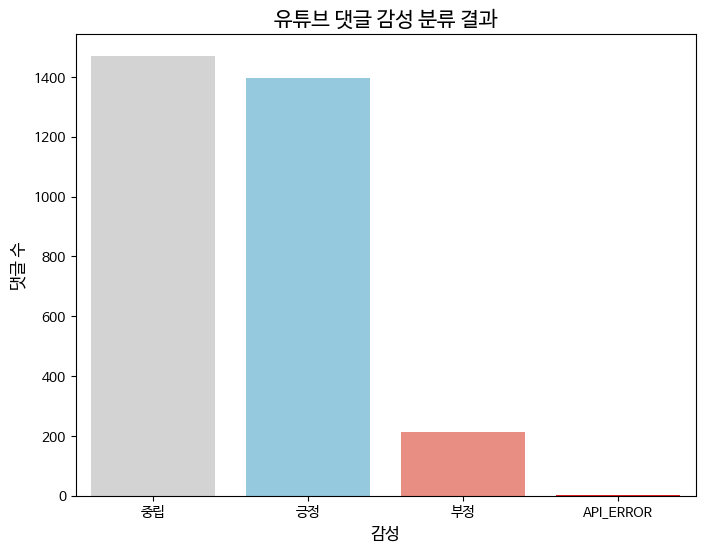


⚠️ API_ERROR 발생 건수: 1개. 해당 댓글은 확인이 필요합니다.


In [ ]:
# @title 7. 분석 결과 통계 및 시각화
if 'df_final' not in locals():
    if os.path.exists(FINAL_PATH):
        df_final = pd.read_csv(FINAL_PATH)
        print(f"최종 결과 파일 로드 완료: {FINAL_PATH}")
    else:
        print("❌ 최종 분석 결과 파일이 없어 분석을 건너뜁니다. Cell 6을 먼저 실행하세요.")
        df_final = None

if df_final is not None:
    # 1. 감성 분류 결과 집계
    sentiment_counts = df_final['sentiment'].value_counts(dropna=False)
    print("\n" + "="*40)
    print("--- 감성 분류 결과 요약 ---")
    print(sentiment_counts)
    print("="*40 + "\n")

    # 2. 시각화
    try:
        import matplotlib.pyplot as plt
        import seaborn as sns

        plt.rcParams['font.family'] = 'NanumBarunGothic'
        plt.rcParams['axes.unicode_minus'] = False

        plot_data = sentiment_counts[sentiment_counts.index.isin(['긍정', '부정', '중립', 'API_ERROR'])]

        plt.figure(figsize=(8, 6))
        colors = {'긍정': 'skyblue', '부정': 'salmon', '중립': 'lightgray', 'API_ERROR': 'red'}
        sns.barplot(x=plot_data.index, y=plot_data.values, palette=[colors.get(i) for i in plot_data.index])

        plt.title('유튜브 댓글 감성 분류 결과', fontsize=15)  # 필요하면 여기 제목만 BHC용으로 바꿔도 됨
        plt.xlabel('감성', fontsize=12)
        plt.ylabel('댓글 수', fontsize=12)
        plt.show()

    except Exception as e:
        print(f"⚠️ 시각화 라이브러리 로드 또는 실행 실패: {e}")
        print("시각화 없이 통계만 출력합니다.")

    # 3. API_ERROR 발생 건수 확인
    error_count = (df_final['sentiment'] == 'API_ERROR').sum()
    if error_count > 0:
        print(f"\n⚠️ API_ERROR 발생 건수: {error_count}개. 해당 댓글은 확인이 필요합니다.")


In [ ]:
# @title 1. 전체 환경 설정 및 데이터 준비

# --- 1. 라이브러리 임포트 ---
import pandas as pd
import os
import time
from google.colab import drive, userdata, output
from IPython.display import display, clear_output, Markdown
import ipywidgets as widgets
from ipywidgets import HBox
import google.generativeai as genai

print("라이브러리 임포트 완료.")

# --- 2. Google Drive 마운트 ---
try:
    drive.mount('/content/drive')
    print("✅ Google Drive 마운트 성공.")
except Exception as e:
    print(f"❌ Google Drive 마운트 실패: {e}")

# --- 3. Gemini API 키 로드 및 클라이언트 초기화 ---
API_KEY_NAME = "gemini_key" # Colab Secrets에 저장된 API 키 이름
MODEL_NAME = "gemini-flash-latest" # 사용할 모델 이름
client = None

try:
    api_key = userdata.get(API_KEY_NAME)
    if not api_key:
        raise ValueError(f"'{API_KEY_NAME}' 이름의 API Key가 비어 있습니다.")

    # API 클라이언트 초기화
    genai.configure(api_key=api_key)
    client = genai.GenerativeModel(MODEL_NAME)
    print(f"✅ API Key 로드 및 '{MODEL_NAME}' 모델 클라이언트 초기화 성공.")

except Exception as e:
    print(f"❌ API Key 로드 또는 클라이언트 초기화 실패: {e}")
    print("Google Colab의 'Secrets(🔑)'에 API 키가 올바르게 설정되었는지 확인하세요.")

# --- 4. 최종 분석 파일 로드 ---
SAVE_DIR = "/content/drive/MyDrive/YoutubeData" # 올바른 저장 경로로 수정
FINAL_FILE_NAME = "통합_분석_결과-bhc.csv"
FINAL_PATH = os.path.join(SAVE_DIR, FINAL_FILE_NAME)
df_final = None

if os.path.exists(FINAL_PATH):
    df_final = pd.read_csv(FINAL_PATH)
    df_final['confidence'] = pd.to_numeric(df_final['confidence'], errors='coerce').fillna(0.0)
    df_final['sentiment'] = df_final['sentiment'].astype(str)
    print(f"✅ 최종 분석 파일 로드 성공: {FINAL_PATH} ({len(df_final)}개 댓글)")
else:
    print(f"❌ 최종 분석 파일을 찾을 수 없습니다. 원본 분석 코드를 먼저 실행하여 파일을 생성해주세요.")

# --- 5. Colab 위젯 활성화 ---
output.enable_custom_widget_manager()
print("\n모든 준비가 완료되었습니다. 다음 셀을 실행하여 컨트롤 패널을 표시하세요.")

라이브러리 임포트 완료.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive 마운트 성공.
✅ API Key 로드 및 'gemini-flash-latest' 모델 클라이언트 초기화 성공.
✅ 최종 분석 파일 로드 성공: /content/drive/MyDrive/YoutubeData/통합_분석_결과-bhc.csv (3081개 댓글)

모든 준비가 완료되었습니다. 다음 셀을 실행하여 컨트롤 패널을 표시하세요.


In [ ]:
# @title 2. 컨트롤 패널: 분석 조건 선택

# 분석 결과가 표시될 전용 출력 영역 위젯 생성
analysis_output_area = widgets.Output()

# Gemini 분석을 수행하는 함수 정의
def run_gemini_analysis(change):
    # 현재 위젯 값 가져오기
    sentiment = sentiment_dropdown.value
    confidence = confidence_slider.value

    # analysis_output_area 위젯 내부의 출력을 제어
    with analysis_output_area:
        clear_output(wait=True)
        print("🔄 Gemini가 분석 중입니다... 잠시만 기다려 주세요.")

        # 데이터 필터링
        filtered_df = df_final[(df_final['sentiment'] == sentiment) & (df_final['confidence'] >= confidence)].copy()
        filtered_count = len(filtered_df)

        if filtered_count == 0:
            clear_output(wait=True)
            display(Markdown(f"### ⚠️ 조건에 해당하는 댓글이 없습니다.\n- **선택 조건:** 감성=`{sentiment}`, Confidence Score >= `{confidence:.1f}`"))
            return

        # Gemini에게 전달할 대표 댓글 샘플링 (최대 10개)
        sample_df = filtered_df.sort_values(by='confidence', ascending=False).head(10)
        comment_examples = "\n".join([f"- {row['text']}" for _, row in sample_df.iterrows()])

        # Gemini에게 보낼 프롬프트 구성
        prompt = f"""
        당신은 'BHC 치킨 신상' 유튜브 영상의 댓글 데이터를 분석하는 전문 데이터 분석가입니다.
        아래는 사용자가 필터링한 댓글 데이터의 요약 정보와 대표적인 댓글 예시입니다.
        이 내용을 바탕으로 심층적인 분석 리포트를 작성해주세요.

        **1. 분석 대상 데이터 요약:**
        - **선택된 감성:** {sentiment}
        - **선택된 Confidence Score 최소값:** {confidence:.1f}
        - **해당 조건의 댓글 수:** {filtered_count}개

        **2. 대표 댓글 예시:**
        {comment_examples}

        **3. 리포트 작성 지시사항 (아래 형식을 반드시 준수하여 Markdown으로 작성):**
        - **분석 요약 및 핵심 함의점:** 필터링된 댓글들의 핵심적인 의견이 무엇인지 1~2 문장으로 요약하고, 이것이 제품/서비스에 어떤 의미를 갖는지 설명해주세요.
        - **주요 하위 주제 클러스터링:** 댓글들에서 공통적으로 나타나는 3-4가지 핵심 주제(예: 디자인, 성능, 가격)를 추출하고, 각 주제에 대한 사용자들의 구체적인 의견을 설명해주세요.
        - **대표 의견:** 가장 대표적이거나 인상 깊은 댓글 2~3개를 인용하고, 왜 이 댓글이 중요하다고 생각하는지 간략히 부연 설명해주세요.
        """

        try:
            # Gemini API 호출
            response = client.generate_content(prompt)

            # 결과 출력 영역을 다시 한번 지우고 최종 결과 표시
            clear_output(wait=True)
            display(Markdown(f"### 🔮 Gemini 분석 리포트 (감성: {sentiment}, Confidence >= {confidence:.1f})"))
            display(Markdown(response.text))

        except Exception as e:
            clear_output(wait=True)
            display(Markdown(f"### ❌ Gemini API 호출 중 오류 발생\n- 오류 내용: {e}"))


# --- 위젯 생성 (셀 1에서 df_final이 로드된 경우에만 실행) ---
if 'df_final' in locals() and df_final is not None and client is not None:
    sentiment_dropdown = widgets.Dropdown(
        options=['긍정', '부정', '중립'], value='부정', description='감성 선택:', style={'description_width': 'initial'}
    )
    confidence_slider = widgets.FloatSlider(
        value=0.7, min=0.0, max=1.0, step=0.1, description='Confidence 최소값:', readout_format='.1f', style={'description_width': 'initial'}
    )

    # 위젯 값이 변경될 때마다 run_gemini_analysis 함수가 실행되도록 연결
    sentiment_dropdown.observe(run_gemini_analysis, names='value')
    confidence_slider.observe(run_gemini_analysis, names='value')

    # 이 셀에 컨트롤러 표시
    display(HBox([sentiment_dropdown, confidence_slider]))

    # 초기 로딩 시 분석 함수를 한 번 호출하여 초기 결과를 표시
    run_gemini_analysis(None)
else:
    print("❌ 분석을 시작할 수 없습니다. 셀 1을 실행하여 데이터와 API 클라이언트를 먼저 준비해주세요.")

In [ ]:
# @title 3. Gemini 실시간 분석 리포트

# 셀 2에서 생성하고 제어하는 analysis_output_area를 이 셀에 표시합니다.
# 위의 컨트롤 패널을 조작하면 이곳의 내용이 실시간으로 변경됩니다.

if 'analysis_output_area' in locals():
    display(analysis_output_area)
else:
    print("❌ 컨트롤 패널(셀 2)을 먼저 실행해주세요.")

Output()

In [ ]:
# @title 4. [자동화] 최적 Confidence 탐색 (Pro 모델 최종 분석)

import re
import time
from IPython.display import display, Markdown, clear_output

# --- 0. 실행 전 환경 확인 ---
if 'client' not in locals() or 'df_final' not in locals() or client is None or df_final is None:
    print("❌ 실행을 중단합니다. 셀 1을 먼저 실행하여 API 클라이언트와 데이터를 준비해주세요.")
else:
    # --- 1. 기본 분석 리포트 생성 (Flash 모델 사용) ---
    print("="*60)
    print(f"🤖 1단계: Flash 모델({client.model_name})로 12개 케이스의 기본 리포트를 생성합니다.")
    print("="*60)

    results_storage = {}
    sentiments_to_run = ['긍정', '부정']
    confidence_levels = [i / 10 for i in range(5, 11)] # 0.5 ~ 1.0

    for sentiment in sentiments_to_run:
        results_storage[sentiment] = {}
        for conf_level in confidence_levels:
            print(f"🔄 [{sentiment} / {conf_level:.1f}] 케이스 분석 중...")

            filtered_df = df_final[(df_final['sentiment'] == sentiment) & (df_final['confidence'] >= conf_level)]

            if len(filtered_df) < 3:
                report_text = "데이터 부족으로 분석을 건너뛰니다."
            else:
                sample_df = filtered_df.sort_values(by='confidence', ascending=False).head(10)
                comment_examples = "\n".join([f"- {row['text']}" for _, row in sample_df.iterrows()])

                prompt = f"""
                유튜브 댓글 데이터 분석 리포트를 작성해주세요.
                - 분석 대상: 감성='{sentiment}', Confidence Score >= {conf_level:.1f} (총 {len(filtered_df)}개)
                - 대표 댓글:
                {comment_examples}

                - 작성 지시: 위 데이터를 바탕으로 핵심 요약, 주요 주제, 대표 의견을 포함한 상세 분석 리포트를 Markdown 형식으로 작성.
                """
                try:
                    # 기본 분석은 기존의 client (Flash 모델) 사용
                    response = client.generate_content(prompt)
                    report_text = response.text
                except Exception as e:
                    report_text = f"API 오류: {e}"

            results_storage[sentiment][conf_level] = report_text
            time.sleep(1)

    print("\n✅ 1단계: 기본 리포트 생성을 완료했습니다.")

    # --- 2. 최종 결론 도출 (Pro 모델 사용) ---
    print("\n\n" + "="*60)
    print(f"🤖 2단계: Pro 모델(gemini-2.5-pro)로 최종 결론을 도출합니다.") # 모델 이름 업데이트
    print("="*60)

    try:
        # 사용 가능한 모델 목록 출력 (디버깅용)
        print("사용 가능한 모델 목록:")
        for m in genai.list_models():
            if "generateContent" in m.supported_generation_methods:
                print(f"- {m.name}")

        # 이 단계에서만 Pro 모델 클라이언트를 별도로 초기화
        PRO_MODEL_NAME = "gemini-2.5-pro" # 모델 이름을 'gemini-2.5-pro'로 변경
        pro_client = genai.GenerativeModel(PRO_MODEL_NAME)
        print(f"✅ 고급 분석을 위해 '{PRO_MODEL_NAME}' 모델을 준비했습니다.")
    except Exception as e:
        print(f"❌ Pro 모델 초기화 실패: {e}. 실행을 중단합니다.")
        # Pro 모델이 없으면 실행 중단
        pro_client = None

    if pro_client:
        best_reports_analysis = {}

        for sentiment in sentiments_to_run:
            print(f"\n▶️ '{sentiment}' 감성의 베스트 리포트를 Pro 모델이 심층 분석 중... (시간이 소요될 수 있습니다)")

            reports_to_evaluate = ""
            for conf_level, report in results_storage[sentiment].items():
                reports_to_evaluate += f"\n\n--- [리포트 후보 {conf_level:.1f}] ---\n{report}"

            # Pro 모델의 'Thinking Budget'을 최대로 활용하기 위한 고도화된 프롬프트
            evaluation_prompt = f"""
            당신은 수석 데이터 과학자(Principal Data Scientist)입니다.
            주니어 분석가들이 동일한 '{sentiment}' 감성 데이터에 대해 Confidence 임계값만 다르게 설정하여 아래와 같이 6개의 분석 리포트 초안을 제출했습니다.
            당신의 임무는 이 6개의 초안을 면밀히 검토하여, 비즈니스 의사결정에 가장 큰 영감을 줄 수 있는 단 하나의 '베스트 리포트'를 선정하고 그 이유를 종합적으로 설명하는 것입니다.

            **[평가 대상 리포트 목록]**
            {reports_to_evaluate}

            **[최종 보고서 작성 지시사항]**
            아래 형식에 맞춰 Markdown으로 상세한 최종 보고서를 작성해주세요. 당신의 깊이 있는 추론 능력을 보여주세요.

            1.  **최적의 Confidence 임계값:**
                - 베스트 리포트에 해당하는 Confidence 임계값을 숫자(예: `0.7`) 하나만 명시해주세요.

            2.  **선정 핵심 이유 (Executive Summary):**
                - 왜 해당 Confidence 임계값의 리포트가 가장 뛰어난지 2~3문장으로 요약해주세요. (예: 노이즈를 효과적으로 제거하면서도 핵심 의견을 충분히 포착했기 때문...)

            3.  **심층 비교 분석:**
                - **선정된 리포트의 강점:** 이 리포트가 다른 리포트들에 비해 구체적으로 어떤 점에서 뛰어난지 (예: 발견된 주제의 구체성, 제시된 의견의 대표성, 숨겨진 인사이트 발견 등) 상세히 분석해주세요.
                - **탈락한 리포트들의 한계점:** 너무 낮거나 높은 임계값의 리포트들이 왜 최적으로 선택되지 못했는지 구체적인 이유를 비교하며 설명해주세요. (예: 0.5는 너무 일반적인 의견이 많아 핵심 파악이 어렵고, 1.0은 의견이 너무 편향되어 전체를 대변하지 못함 등)
            """

            try:
                # Pro 모델을 사용하여 최종 결론 도출
                eval_response = pro_client.generate_content(evaluation_prompt)
                best_reports_analysis[sentiment] = eval_response.text
            except Exception as e:
                best_reports_analysis[sentiment] = f"평가 중 API 오류 발생: {e}"
            time.sleep(1)

        # --- 3. 최종 결과 보고 ---
        clear_output(wait=True)
        print("="*60)
        print("🏆 [Pro 모델] 최종 자동 분석 및 평가 결과 🏆")
        print("="*60 + "\n")

        for sentiment in sentiments_to_run:
            display(Markdown(f"## 💎 `{sentiment}` 감성 분석 최종 결론"))

            # Pro 모델이 생성한 통찰력 있는 분석 결과 전체를 그대로 출력
            analysis_result = best_reports_analysis.get(sentiment, "결과를 가져오는 데 실패했습니다.")
            display(Markdown(analysis_result))

            # 베스트 리포트 원문도 함께 표시
            try:
                # Pro 모델의 답변에서 최적 Confidence 값 추출
                best_conf_str = re.search(r'(\d\.\d)', analysis_result)
                if best_conf_str:
                    best_conf = float(best_conf_str.group(1))
                    best_report_text = results_storage[sentiment].get(best_conf, "리포트를 가져올 수 없습니다.")
                else:
                    best_report_text = "베스트 리포트 원문을 자동으로 표시하는 데 실패했습니다. (Confidence 값 추출 불가)"

                display(Markdown(f"\n---\n"))
                display(Markdown(f"### 📄 참고: 선정된 베스트 리포트 원문 (Flash 모델 작성본)"))
                display(Markdown(best_report_text))
            except Exception as e:
                # 숫자 추출 실패 시 원문 표시는 건너뛰기
                display(Markdown(f"*베스트 리포트 원문을 자동으로 표시하는 데 실패했습니다. 오류: {e}*"))

            display(Markdown(f"\n" + "="*80 + "\n"))

🏆 [Pro 모델] 최종 자동 분석 및 평가 결과 🏆



## 💎 `긍정` 감성 분석 최종 결론

수석 데이터 과학자로서 주니어 분석가들이 제출한 6개의 리포트 초안을 면밀히 검토했습니다. 모든 리포트가 동일한 핵심 인사이트(제품 성공, 팬덤 반응, 마케팅 극찬)를 담고 있었지만, Confidence 임계값 설정에 따라 분석의 깊이와 비즈니스 활용도가 미묘하게 달라졌습니다.

아래는 제가 선정한 베스트 리포트와 그 선정 이유에 대한 종합적인 분석입니다.

---

### 1. 최적의 Confidence 임계값:

`0.8`

### 2. 선정 핵심 이유 (Executive Summary):

Confidence 임계값 0.8을 기준으로 작성된 리포트는 **'신호 선명도(Signal Clarity)'와 '데이터 대표성(Data Representativeness)'** 사이에서 최적의 균형을 이루었습니다. 이 리포트는 의미가 모호하거나 약한 긍정 노이즈(Noise)를 효과적으로 제거하면서도, 핵심 팬덤의 열광적인 반응을 놓치지 않는 충분한 데이터 볼륨(1,251건)을 확보했습니다. 그 결과, 분석된 인사이트가 가장 날카롭고 구체적이며, 이를 바탕으로 도출된 마케팅 제언이 즉시 실행 가능할 정도로 높은 비즈니스 가치를 지니고 있습니다.

### 3. 심층 비교 분석:

#### **선정된 리포트(0.8)의 강점:**

임계값 0.8 리포트는 다른 후보군을 압도하는 몇 가지 핵심적인 강점을 보여주었습니다.

*   **인사이트의 질적 깊이 (Qualitative Depth):** 단순히 "제품 반응이 좋다"는 표면적인 결론을 넘어, **'왜' 좋은지**에 대한 심층적인 원인을 명확히 제시합니다. 예를 들어, '한음의 발골' 장면이 단순한 먹방을 넘어 **'진정성을 통한 제품 신뢰도 확보'**라는 사회적 증거(Social Proof)로 작용했음을 구체적으로 분석한 점이 뛰어납니다. 이는 다른 리포트들보다 한 단계 더 나아간 전략적 해석입니다.

*   **최고의 실행 가능성 (High Actionability):** 이 리포트의 '마케팅 제언' 섹션은 분석 결과를 비즈니스 행동으로 직접 연결하는 능력이 가장 탁월합니다. "'하누리즈 추천 세트' 구성", "장기적 파트너십 검토" 등은 데이터에 기반한 매우 구체적이고 현실적인 제안입니다. 이는 단순 요약을 넘어, 분석의 최종 목적인 '의사결정 지원'을 완벽하게 수행하고 있음을 의미합니다.

*   **최적의 균형점 (Optimal Trade-off):** 임계값 0.8은 1,251건의 데이터를 분석 대상으로 삼습니다. 이는 가장 넓은 범위(0.5, 1,394건)에서 약 10%의 노이즈를 제거한 수치입니다. 이 과정을 통해 "재밌네요"와 같은 일반적인 긍정 표현을 걸러내고, "감다살 상 드려야 합니다", "인생 손해볼뻔"과 같이 감정이 풍부하고 구체적인 의견에 집중할 수 있었습니다. 즉, 데이터의 양을 과도하게 희생하지 않으면서도 분석의 질을 극대화하는 최적의 지점을 찾아냈습니다.

#### **탈락한 리포트들의 한계점:**

*   **너무 낮은 임계값 (0.5, 0.6): '신호가 희석된' 리포트**
    *   **한계점:** 이 리포트들은 가장 많은 데이터를 포함하지만, "좋아요", "기대됩니다"와 같이 감정의 강도가 낮거나 의도가 불분명한 '약한 긍정(Weak Positives)' 댓글을 포함할 가능성이 높습니다. 이는 마치 깨끗한 물에 흐린 물을 섞는 것과 같아, 핵심 고객의 열광적인 반응이라는 강력한 신호가 희석되는 결과를 낳습니다.
    *   **비즈니스 관점:** 의사결정자는 '얼마나 많은' 사람이 긍정적인지보다 **'얼마나 강렬하게' 긍정적인지**를 파악하고 싶어 합니다. 0.5 리포트는 전자에 치우쳐 후자의 선명도를 놓치기 때문에 전략적 가치가 상대적으로 낮습니다.

*   **준수한 임계값 (0.7): '좋지만, 최고는 아닌' 리포트**
    *   **한계점:** 0.7 리포트는 매우 훌륭하며 0.8 리포트와 거의 흡사한 결론을 내립니다. 하지만 0.8 리포트가 약 100여 건의 데이터를 추가로 필터링함으로써 얻게 된 **'결론의 예리함'**과 **'제안의 구체성'**에서 근소한 차이를 보입니다. 0.8 리포트가 "최고의 명장면"과 "마케팅 제언"을 더 자신감 있게 제시하는 것은 더 정제된 데이터를 분석했기 때문입니다.

*   **너무 높은 임계값 (0.9, 1.0): '편향된 확신'의 리포트**
    *   **한계점 (0.9):** 912건의 데이터는 여전히 유의미하지만, 이는 전체 긍정 의견의 일부인 '골수 팬덤(Core Fandom)' 또는 '극단적 옹호자(Hyper-advocates)'의 목소리에 과도하게 집중할 위험이 있습니다. 이들의 의견은 중요하지만, 이들만으로 전체 긍정 여론을 대표한다고 보기는 어렵습니다. 이는 '확증 편향'에 빠질 수 있는 위험한 임계값입니다.
    *   **한계점 (1.0):** 단 6건의 데이터로 작성된 이 리포트는 **분석이 아닌 '일화(Anecdote)'**에 불과합니다. Confidence 1.0은 모델이 100% 확신하는, 매우 강렬하고 명확한 표현만을 추출하지만, 샘플 사이즈가 너무 작아 통계적 유의미성이 전혀 없습니다. 이 6개의 댓글이 전체 긍정 여론을 대표할 수 없으며, 이를 기반으로 한 의사결정은 매우 위험합니다. 이는 '정확성(Precision)'을 얻기 위해 '재현성/대표성(Recall/Representativeness)'을 완전히 포기한 최악의 사례입니다.

결론적으로, **임계값 0.8 리포트**는 비즈니스가 필요로 하는 가장 정제되고, 신뢰할 수 있으며, 실행 가능한 인사이트를 제공하는 유일한 선택지입니다. 이 리포트를 최종본으로 채택하고, 분석 결과를 즉시 마케팅 전략 회의에 상정할 것을 권고합니다.


---


### 📄 참고: 선정된 베스트 리포트 원문 (Flash 모델 작성본)

...

물론입니다. 주니어 분석가들의 초안을 면밀히 검토한 후, 수석 데이터 과학자로서 다음과 같이 최종 보고서를 작성합니다.

---

### 1. 최적의 Confidence 임계값:

`0.7`

### 2. 선정 핵심 이유 (Executive Summary):

Confidence 임계값 0.7을 사용한 리포트는 불필요한 노이즈(모호하거나 강도가 약한 부정 의견)를 효과적으로 제거하면서도, 비즈니스 의사결정에 필수적인 핵심 부정 요인을 충분한 데이터 양으로 확보하는 최적의 균형점을 보여주었습니다. 특히, 다른 리포트에서는 명확히 드러나지 않았던 **'중량(양)' 문제를 발굴**하여 '가격' 및 '품질'과 결합된 **'총체적 가성비(VFM) 붕괴'**라는 핵심 인사이트를 도출해낸 점이 가장 뛰어납니다.

### 3. 심층 비교 분석:

#### **선정된 리포트(0.7)의 강점:**

[리포트 후보 0.7]은 단순히 부정적인 의견을 나열하는 것을 넘어, 소비자의 분노가 어떤 논리적 구조를 통해 형성되는지를 가장 명확하게 보여주었습니다.

1.  **핵심 인사이트의 구체성 및 발견:**
    다른 모든 리포트가 '가격'과 '품질(바삭함)'이라는 두 가지 축에 집중한 반면, 0.7 리포트는 유일하게 **"중량 처참하네"**라는 구체적인 의견을 포착하여 **'가성비(Value for Money)'**라는 제3의 핵심 축을 명확히 제시했습니다. "24900원인데 눈대중으로 봐도 중량 처참하네. 난 저 돈 주고 사먹느니 차라리 애슐리 가고 말지." 라는 대표 의견은 가격, 양, 그리고 **구체적인 대체제(애슐리)**까지 언급하며 현 문제의 심각성을 가장 실질적으로 보여주는 강력한 증거입니다.

2.  **최적의 신호 대 잡음비 (Signal-to-Noise Ratio):**
    임계값 0.7은 N=186이라는 신뢰도 있는 표본 크기를 유지하면서도, 분석의 초점을 흐릴 수 있는 약한 강도의 불만들을 성공적으로 걸러냈습니다. 이는 임계값 0.5(N=208)나 0.6(N=207)과 비교했을 때 약 10%의 노이즈를 제거하여, 보다 정제되고 강력한 핵심 의견에 집중할 수 있게 만들었습니다.

3.  **균형 잡힌 주제 구성:**
    보고서는 '품질 실패', '가성비 붕괴', '브랜드 불신', 'R&D 비판'이라는 네 가지 주제를 균형 있게 다루고 있습니다. 이는 소비자의 불만이 단편적인 이슈가 아니라, 제품 기획부터 가격 책정, 최종적인 브랜드 신뢰도까지 연쇄적으로 붕괴하고 있음을 입체적으로 보여줍니다. 반면, 더 높은 임계값의 리포트들은 감정적 비난에 치우쳐 이러한 다층적 구조를 놓치는 경향이 있습니다.

#### **탈락한 리포트들의 한계점:**

각 리포트들은 Confidence 임계값 설정에 따른 전형적인 트레이드오프(Trade-off) 문제를 보여주며, 이것이 왜 0.7이 최적의 선택인지를 역설적으로 증명합니다.

*   **임계값이 너무 낮은 경우 (0.5, 0.6):**
    *   **한계점: 인사이트의 희석 (Insight Dilution)**
    *   **상세 설명:** N=208, N=207이라는 가장 큰 데이터 볼륨을 확보했지만, 분석 결과는 다소 평면적입니다. '가격이 비싸다', '바삭하지 않다'는 표면적인 사실을 나열하는 데 그치며, 이 두 요소가 어떻게 결합하여 어떤 시너지를 내는지에 대한 깊이 있는 분석이 부족합니다. 특히 0.7 리포트가 발견한 '중량'이라는 결정적 요인을 놓침으로써, 문제의 본질인 '가성비' 이슈를 수면 위로 끌어올리지 못했습니다. 이는 마치 큰 그물로 물고기를 잡았지만, 정작 가장 중요한 월척은 놓친 것과 같습니다.

*   **임계값이 너무 높은 경우 (0.8, 0.9):**
    *   **한계점: 표본 편향 및 맥락 상실 (Sample Bias & Context Loss)**
    *   **상세 설명:** N=131, N=63으로 표본이 급격히 줄어들면서, 분석은 "망해라", "노답" 등 극단적이고 감정적인 표현에만 집중됩니다. 이는 문제의 *'심각성'*을 확인하는 데는 유용하지만, 문제의 *'원인'*을 진단하는 데는 한계가 있습니다. 예를 들어, 0.7 리포트가 제시한 "양념을 바르면 당연히 눅눅해지지 그걸 바삭킹이라고 출시를 하는" 과 같은 논리적 비판이나, "애슐리 가고 말지"와 같은 구체적인 비교 맥락이 사라지고 순수한 분노의 표출만 남게 됩니다. 의사결정자는 '왜' 분노했는지를 알아야 해결책을 찾을 수 있는데, 이 리포트들은 '얼마나' 분노했는지만을 보여주어 구체적인 해결책을 도출하기 어렵게 만듭니다.

*   **임계값이 극단적으로 높은 경우 (1.0):**
    *   **한계점: 분석 불가 (Analysis Void)**
    *   **상세 설명:** "데이터 부족"이라는 결과는 임계값을 1.0으로 설정하는 것이 현실적으로 불가능함을 보여줍니다. 이는 완벽한 확신(Confidence=1.0)을 가진 데이터만 찾으려다 결국 아무런 데이터도 얻지 못하는 '완벽주의의 함정'에 빠진 경우입니다. 이는 분석의 목적이 학문적 순수성이 아니라 비즈니스 가치 창출에 있음을 상기시켜 줍니다.

결론적으로, **리포트 0.7**은 데이터의 양과 질, 분석의 깊이와 넓이, 문제 현상과 원인 진단 사이에서 가장 뛰어난 균형감을 보여주었기에, 비즈니스의 다음 단계를 결정하는 데 가장 큰 영감을 주는 '베스트 리포트'로 선정합니다.


---


### 📄 참고: 선정된 베스트 리포트 원문 (Flash 모델 작성본)

# 유튜브 댓글 데이터 분석 리포트: 부정 감성 분석

## I. 핵심 요약 (Executive Summary)

본 리포트는 감성 분석 결과 '부정(Negative)' 감성을 나타내며 신뢰도 점수 0.7점 이상을 기록한 유튜브 댓글 186건을 대상으로 진행되었습니다.

분석 결과, 소비자들의 부정적인 의견은 크게 **'제품의 핵심 속성(바삭함) 실패'**와 **'과도한 가격 및 처참한 중량으로 인한 가성비 붕괴'** 두 축으로 집중되었습니다. 소비자들은 신제품이 고가 정책을 취했음에도 불구하고 품질이 기대에 미치지 못할 뿐 아니라 양까지 적다는 점에 대해 극심한 실망감과 분노를 표출하고 있습니다.

핵심 키워드는 '안 바삭함', '24900원/26000원', '노답', '망해야 한다' 등이며, 이는 특정 브랜드에 대한 비난을 넘어 국내 치킨 산업 전반의 고가 정책에 대한 강력한 저항으로 확대되고 있습니다.

---

## II. 분석 개요

| 구분 | 내용 |
| :--- | :--- |
| **분석 대상** | 유튜브 댓글 데이터 (총 186건) |
| **필터 조건** | 감성 = 부정 (Negative), Confidence Score $\ge$ 0.7 |
| **주요 이슈** | 신제품 품질 불만족, 고가 정책 및 가성비 논란 |
| **분석 목표** | 소비자의 부정적 인식을 유발하는 핵심 요인 파악 |

---

## III. 주요 분석 주제 및 상세 의견

수집된 부정 댓글을 바탕으로 소비자 불만의 핵심 동인을 다음과 같이 4가지 주제로 분류하였습니다.

### 1. 제품 품질의 근본적 실패 및 명칭 불일치
소비자들은 신제품이 광고하는 핵심 속성, 즉 '바삭함'을 전혀 충족시키지 못한다고 지적합니다. 특히 양념을 바르는 방식이 바삭함을 해치는 근본적인 문제임을 지적하며, 제품 기획 과정에 대한 강한 불신을 드러냅니다.

*   **키워드:** 바삭킹, 눅눅, 안 바삭해, 노답 메뉴.
*   **분석:** 제품명에 '바삭'이라는 단어를 사용했음에도 실제 식감이 정반대라는 점이 소비자의 조롱과 분노를 유발했습니다. 이는 단순한 품질 저하를 넘어 마케팅 메시지와의 심각한 괴리로 인식됩니다.

### 2. 과도한 가격 책정 및 가치 붕괴 (Value for Money, VFM)
댓글에서 가장 빈번하게 언급된 수치는 가격(24,900원, 26,000원)입니다. 소비자들은 이 가격이 '선 넘는' 수준이라고 판단하며, 특히 가격 대비 턱없이 적은 중량(양)에 대해 강력하게 비판합니다.

*   **키워드:** 24900원, 26000원, 중량 처참, 눈대중, 선넘는데.
*   **분석:** 소비자들이 치킨 구매를 포기하고 차라리 다른 외식 대안(예: 애슐리)을 언급할 정도로, 해당 제품의 가성비는 완전히 무너졌다고 인식됩니다. 높은 가격이 기대 심리를 높였으나, 중량 문제가 실망감을 극대화했습니다.

### 3. 브랜드 및 업계 전반에 대한 강력한 실망과 불매 선언
개별 제품에 대한 실망을 넘어, 해당 브랜드를 포함한 국내 치킨 업계 전반의 고가 및 소량 정책에 대한 강한 반감이 표출됩니다. 이는 단순 비판을 넘어 브랜드의 몰락을 기원하는 극단적인 부정 감성으로 나타납니다.

*   **키워드:** 망해야 한다, 교촌은 그냥 망해라 제발, 절대 안 먹어.
*   **분석:** 이는 소비자들이 현재 치킨 가격에 대해 일종의 '임계점'에 도달했으며, 품질과 양이 뒷받침되지 않는 고가 정책에 대해 강력한 구매 거부 의사를 밝히고 있음을 시사합니다.

### 4. 부실한 제품 기획 및 품평 시스템 비판
소비자들은 이처럼 명백한 품질 문제가 있음에도 제품이 출시된 과정을 이해하지 못하고, 기업의 R&D 및 품평 시스템에 근본적인 문제가 있다고 비판합니다.

*   **키워드:** 품평회를 틀니 낀 노인한테 시켰냐, 그걸 바삭킹이라고 출시를 하는.
*   **분석:** 이는 제품의 실패가 시장 조사나 최종 점검 과정의 부실에서 비롯되었다고 판단하는 소비자의 인식을 반영합니다.

---

## IV. 대표 의견 (Representative Opinions)

수집된 댓글 중 핵심 불만을 가장 잘 대변하는 의견을 주제별로 분류하였습니다.

| 주제 | 대표 댓글 |
| :--- | :--- |
| **가격 및 가성비 (VFM)** | "24900원인데 눈대중으로 봐도 중량 처참하네. 난 저 돈 주고 사먹느니 차라리 애슐리 가고 말지." |
| | "양념 26000원은 선넘는데" |
| | "저걸 팔아주는 호구" |
| **제품 품질 및 식감** | "하나도안바삭햌ㅋㅋㅋㅋ" |
| | "이이~ 하나도 안바삭혀!!!!!!!!!!!" |
| | "노답메뉴네" |
| **기획 및 R&D 비판** | "품평회를 틀니 낀 노인한테 시켰냐 ㅋㅋㅋㅋ 양념을 바르면 당연히 눅눅해지지 그걸 바삭킹이라고 출시를 하는.." |
| **브랜드 및 업계 불신** | "우리나라 치킨업계는 다 망해야 한다" |
| | "교촌은 그냥 망해라 제발" |
| | "절대 안먹어 ㅋㅋㅋ" |

---

## V. 시사점 및 제언

### 1. 가격 민감도의 재인식
소비자들은 현재 치킨 가격에 대해 매우 높은 불만을 가지고 있으며, 조금이라도 품질이나 양에서 실망하면 즉각적인 구매 거부로 이어지는 단계입니다. 고가 정책을 유지하려면 **압도적인 품질과 중량**으로 이를 상쇄해야 합니다.

### 2. 마케팅 메시지의 신뢰성 확보
제품명 '바삭킹'이 실제 품질을 반영하지 못해 소비자 신뢰가 크게 하락했습니다. 신제품 출시 시, 핵심 콘셉트와 실제 품질 간의 일치성을 철저히 검증하고, 특히 **양념 치킨의 바삭함 유지**에 대한 기술적 해결이 필수적입니다.

### 3. 내부 품평 시스템 재점검
소비자들이 품평 과정을 비판하는 것은 기업이 시장의 눈높이를 이해하지 못하고 있다는 반증입니다. 소비자들의 실제 피드백을 반영할 수 있는 객관적이고 엄격한 내부 품질 평가 시스템 구축이 시급합니다.


================================================================================
